**Header**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE    = '/content/drive/MyDrive/churn_project/'
DATA    = BASE + 'data/raw/'
PROC    = BASE + 'data/processed/'
RESULTS = BASE + 'results/'

print("✓ Drive mounted and paths set")

Mounted at /content/drive
✓ Drive mounted and paths set


**Import of libraries:**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("✓ Imports done")

✓ Imports done


**Load all 3 datasets:**

In [3]:
import zipfile

# Telecom — combine 80/20 split
telecom_train = pd.read_csv(DATA + 'churn-bigml-80.csv')
telecom_test  = pd.read_csv(DATA + 'churn-bigml-20.csv')
telecom       = pd.concat([telecom_train, telecom_test], ignore_index=True)

# ISP
isp = pd.read_csv(DATA + 'internet_service_churn.csv')

# Insurance — combine train/test
with zipfile.ZipFile(DATA + 'Train.csv.zip', 'r') as z:
    z.extractall(DATA)
with zipfile.ZipFile(DATA + 'Test.csv.zip', 'r') as z:
    z.extractall(DATA)

ins_train = pd.read_csv(DATA + 'Train.csv')
ins_test  = pd.read_csv(DATA + 'Test.csv')
insurance = pd.concat([ins_train, ins_test], ignore_index=True)

datasets = {
    'Insurance' : insurance,
    'ISP'       : isp,
    'Telecom'   : telecom
}

for name, df in datasets.items():
    print(f"{name:12} → shape: {df.shape}")

Insurance    → shape: (45211, 17)
ISP          → shape: (72274, 11)
Telecom      → shape: (3333, 20)


**First look of each dataset**

In [4]:
for name, df in datasets.items():
    print(f"\n{'='*55}")
    print(f"  {name} — first 3 rows")
    print(f"{'='*55}")
    display(df.head(3))
    print(f"\n  Columns: {list(df.columns)}")


  Insurance — first 3 rows


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,labels
0,-0.276515,-0.424429,1.344997,-0.012283,0.076230,1.076648,0.182198,3,0,1,0,0,0,0,10,2,1.0
1,0.853573,0.150991,0.503892,-0.979179,-0.569351,-0.411453,-0.251940,4,1,2,0,1,0,0,0,3,0.0
2,0.947747,-0.173832,1.825628,-0.703478,0.076230,-0.411453,-0.251940,6,1,2,0,0,0,0,5,3,0.0



  Columns: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'labels']

  ISP — first 3 rows


,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1



  Columns: ['id', 'is_tv_subscriber', 'is_movie_package_subscriber', 'subscription_age', 'bill_avg', 'reamining_contract', 'service_failure_count', 'download_avg', 'upload_avg', 'download_over_limit', 'churn']

  Telecom — first 3 rows


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False



  Columns: ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']


In [7]:
# Manually define churn columns since Insurance uses 'labels'
churn_cols = {
    'Insurance' : 'labels',
    'ISP'       : 'churn',
    'Telecom'   : 'Churn'
}

# Verify and show unique values in each churn column
for name, df in datasets.items():
    col = churn_cols[name]
    print(f"{name:12} → churn column: '{col}'")
    print(f"             → dtype: {df[col].dtype}")
    print(f"             → unique values: {df[col].unique()}")
    print(f"             → value counts:\n{df[col].value_counts()}\n")

Insurance    → churn column: 'labels'
             → dtype: float64
             → unique values: [ 1.  0. nan]
             → value counts:
labels
0.0    29941
1.0     3967
Name: count, dtype: int64

ISP          → churn column: 'churn'
             → dtype: int64
             → unique values: [0 1]
             → value counts:
churn
1    40050
0    32224
Name: count, dtype: int64

Telecom      → churn column: 'Churn'
             → dtype: bool
             → unique values: [False  True]
             → value counts:
Churn
False    2850
True      483
Name: count, dtype: int64



In [6]:
# Diagnostic — run this to see ALL column names in each dataset
for name, df in datasets.items():
    print(f"\n{name} columns:")
    for col in df.columns:
        print(f"  '{col}'")


Insurance columns:
  'feature_0'
  'feature_1'
  'feature_2'
  'feature_3'
  'feature_4'
  'feature_5'
  'feature_6'
  'feature_7'
  'feature_8'
  'feature_9'
  'feature_10'
  'feature_11'
  'feature_12'
  'feature_13'
  'feature_14'
  'feature_15'
  'labels'

ISP columns:
  'id'
  'is_tv_subscriber'
  'is_movie_package_subscriber'
  'subscription_age'
  'bill_avg'
  'reamining_contract'
  'service_failure_count'
  'download_avg'
  'upload_avg'
  'download_over_limit'
  'churn'

Telecom columns:
  'State'
  'Account length'
  'Area code'
  'International plan'
  'Voice mail plan'
  'Number vmail messages'
  'Total day minutes'
  'Total day calls'
  'Total day charge'
  'Total eve minutes'
  'Total eve calls'
  'Total eve charge'
  'Total night minutes'
  'Total night calls'
  'Total night charge'
  'Total intl minutes'
  'Total intl calls'
  'Total intl charge'
  'Customer service calls'
  'Churn'


**Missing values check:**

In [8]:
print("MISSING VALUES SUMMARY")
print("="*55)
for name, df in datasets.items():
    total_missing = df.isnull().sum().sum()
    print(f"\n{name}:")
    if total_missing == 0:
        print("  ✓ No missing values")
    else:
        missing = df.isnull().sum()
        print(missing[missing > 0])
        print(f"  Total missing cells: {total_missing}")

MISSING VALUES SUMMARY

Insurance:
labels    11303
dtype: int64
  Total missing cells: 11303

ISP:
reamining_contract    21572
download_avg            381
upload_avg              381
dtype: int64
  Total missing cells: 22334

Telecom:
  ✓ No missing values


**Class imabalnace check:**

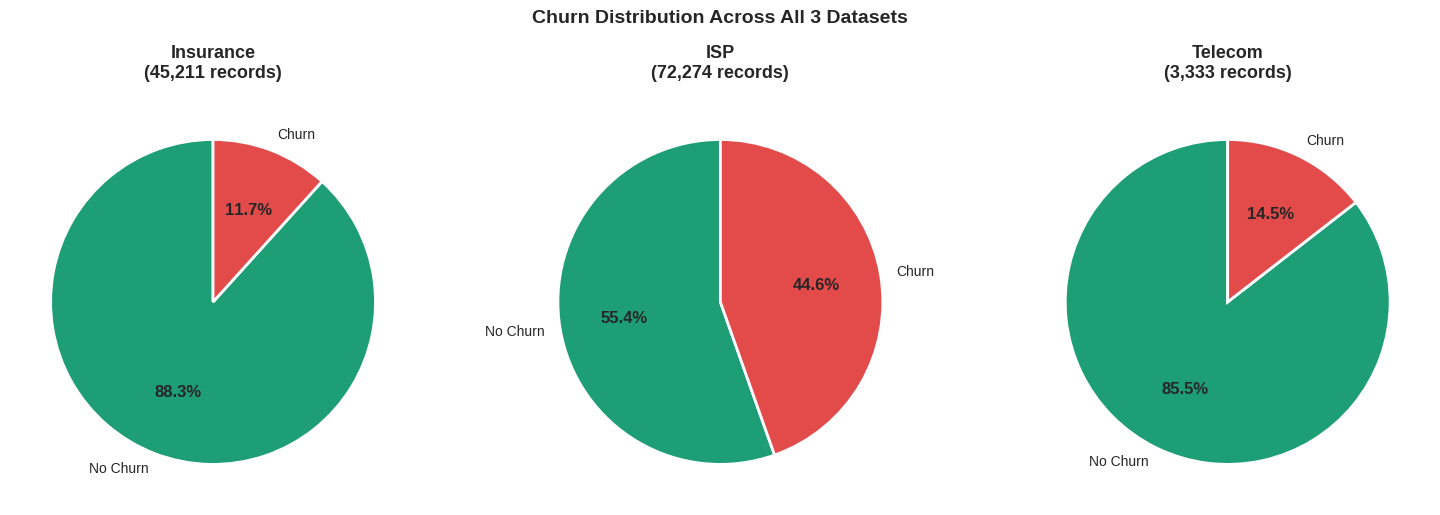

✓ Saved to results/churn_distribution.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, df) in zip(axes, datasets.items()):
    churn_col = churn_cols[name]
    counts    = df[churn_col].value_counts()

    colors = ['#1D9E75', '#E24B4A']
    wedges, texts, autotexts = ax.pie(
        counts,
        labels    = ['No Churn', 'Churn'],
        autopct   = '%1.1f%%',
        colors    = colors,
        startangle= 90,
        wedgeprops= dict(edgecolor='white', linewidth=2)
    )
    for t in autotexts:
        t.set_fontsize(12)
        t.set_fontweight('bold')

    ax.set_title(f'{name}\n({df.shape[0]:,} records)',
                 fontsize=13, fontweight='bold', pad=15)

plt.suptitle('Churn Distribution Across All 3 Datasets',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS + 'churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to results/churn_distribution.png")

**Dataset summary statistics:**

In [10]:
print("DATASET SUMMARY")
print("="*55)

for name, df in datasets.items():
    churn_col  = churn_cols[name]
    churn_vals = df[churn_col]

    # Handle all possible churn value types
    if churn_vals.dtype == bool:
        churn_rate = churn_vals.mean() * 100
    elif churn_vals.dtype == object:
        churn_rate = (
            churn_vals.str.strip()
                      .str.lower()
                      .isin(['yes', 'true', '1', 'churn'])
        ).mean() * 100
    else:
        # numeric: 0/1 or similar
        churn_rate = (churn_vals > 0).mean() * 100

    print(f"\n{name}")
    print(f"  Rows         : {df.shape[0]:,}")
    print(f"  Columns      : {df.shape[1]}")
    print(f"  Churn rate   : {churn_rate:.1f}%")
    print(f"  Numeric cols : {df.select_dtypes(include='number').shape[1]}")
    print(f"  Object cols  : {df.select_dtypes(include='object').shape[1]}")

DATASET SUMMARY

Insurance
  Rows         : 45,211
  Columns      : 17
  Churn rate   : 8.8%
  Numeric cols : 17
  Object cols  : 0

ISP
  Rows         : 72,274
  Columns      : 11
  Churn rate   : 55.4%
  Numeric cols : 11
  Object cols  : 0

Telecom
  Rows         : 3,333
  Columns      : 20
  Churn rate   : 14.5%
  Numeric cols : 16
  Object cols  : 3


**Correlation Matrix:**

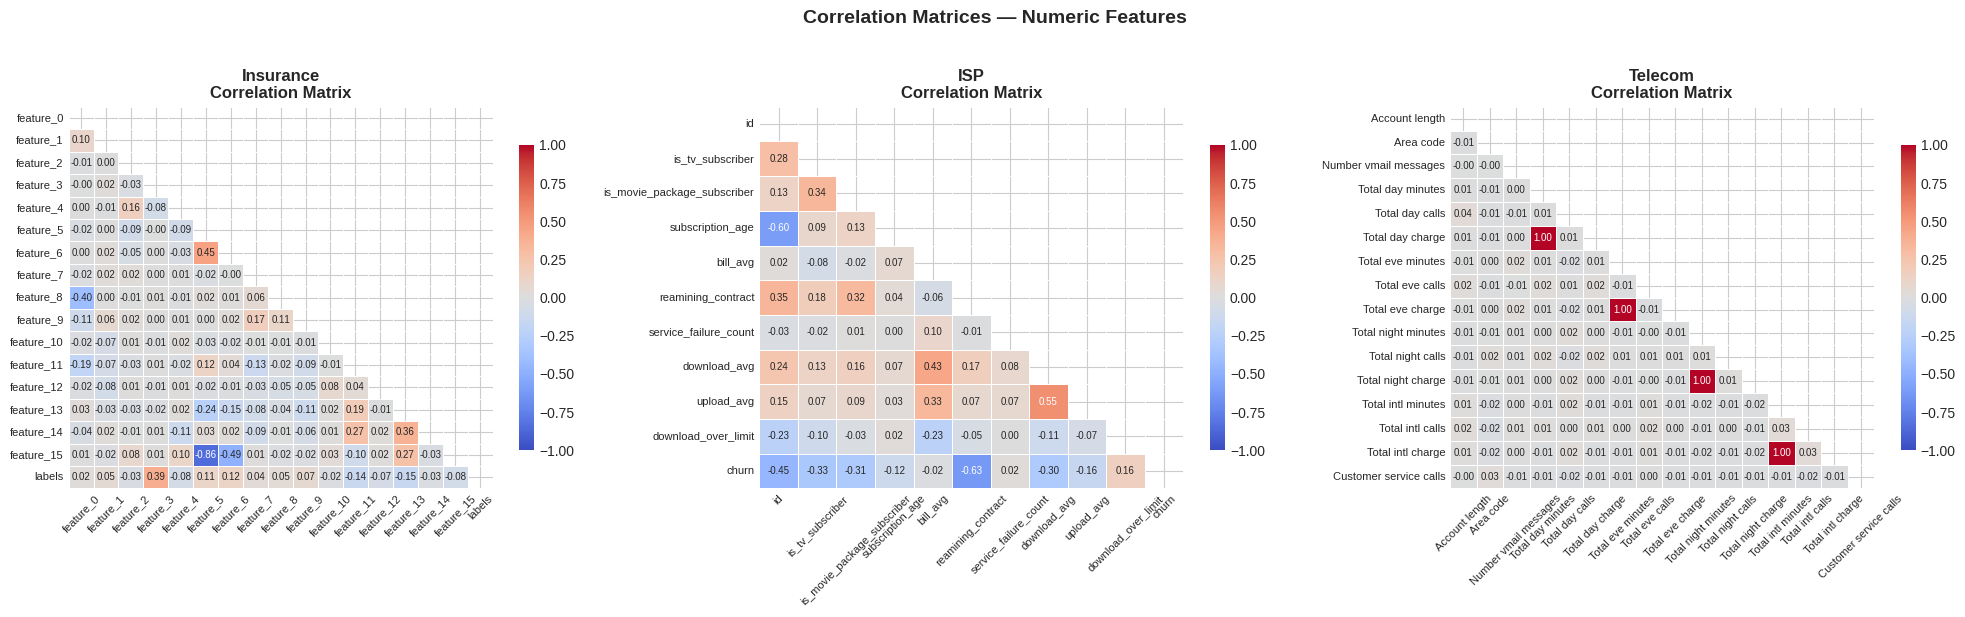

✓ Saved to results/correlation_matrix.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, df) in zip(axes, datasets.items()):
    numeric_df = df.select_dtypes(include='number')
    corr       = numeric_df.corr()

    mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

    sns.heatmap(
        corr,
        ax          = ax,
        mask        = mask,
        annot       = True,
        fmt         = '.2f',
        cmap        = 'coolwarm',
        linewidths  = 0.5,
        annot_kws   = {'size': 7},
        vmin        = -1,
        vmax        = 1,
        cbar_kws    = {'shrink': 0.8}
    )
    ax.set_title(f'{name}\nCorrelation Matrix',
                 fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Correlation Matrices — Numeric Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS + 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to results/correlation_matrix.png")

**Feature Distribution by churn:**

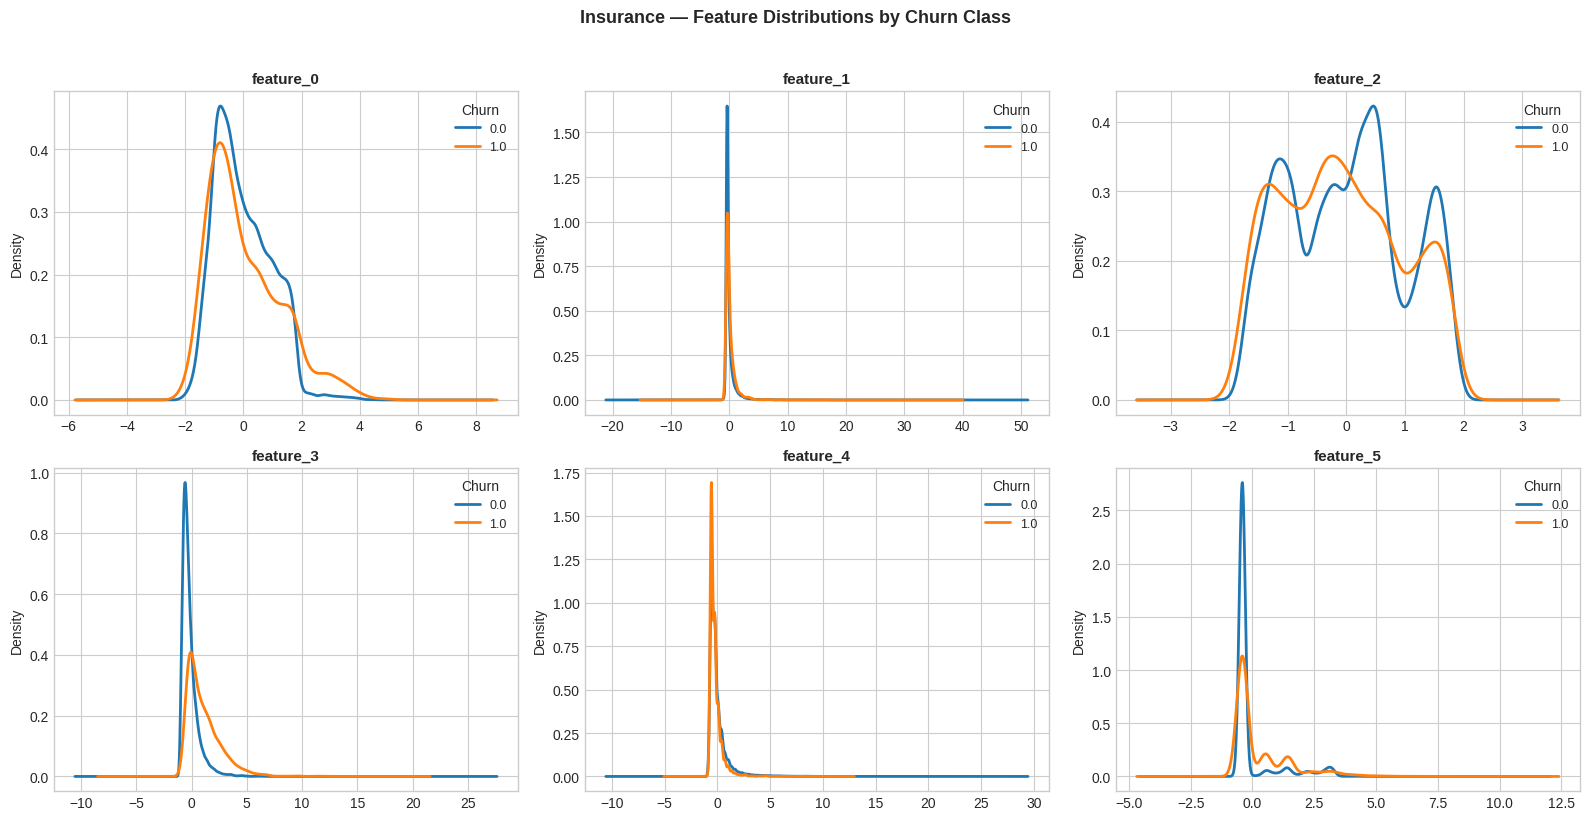

✓ Saved Insurance distribution plot


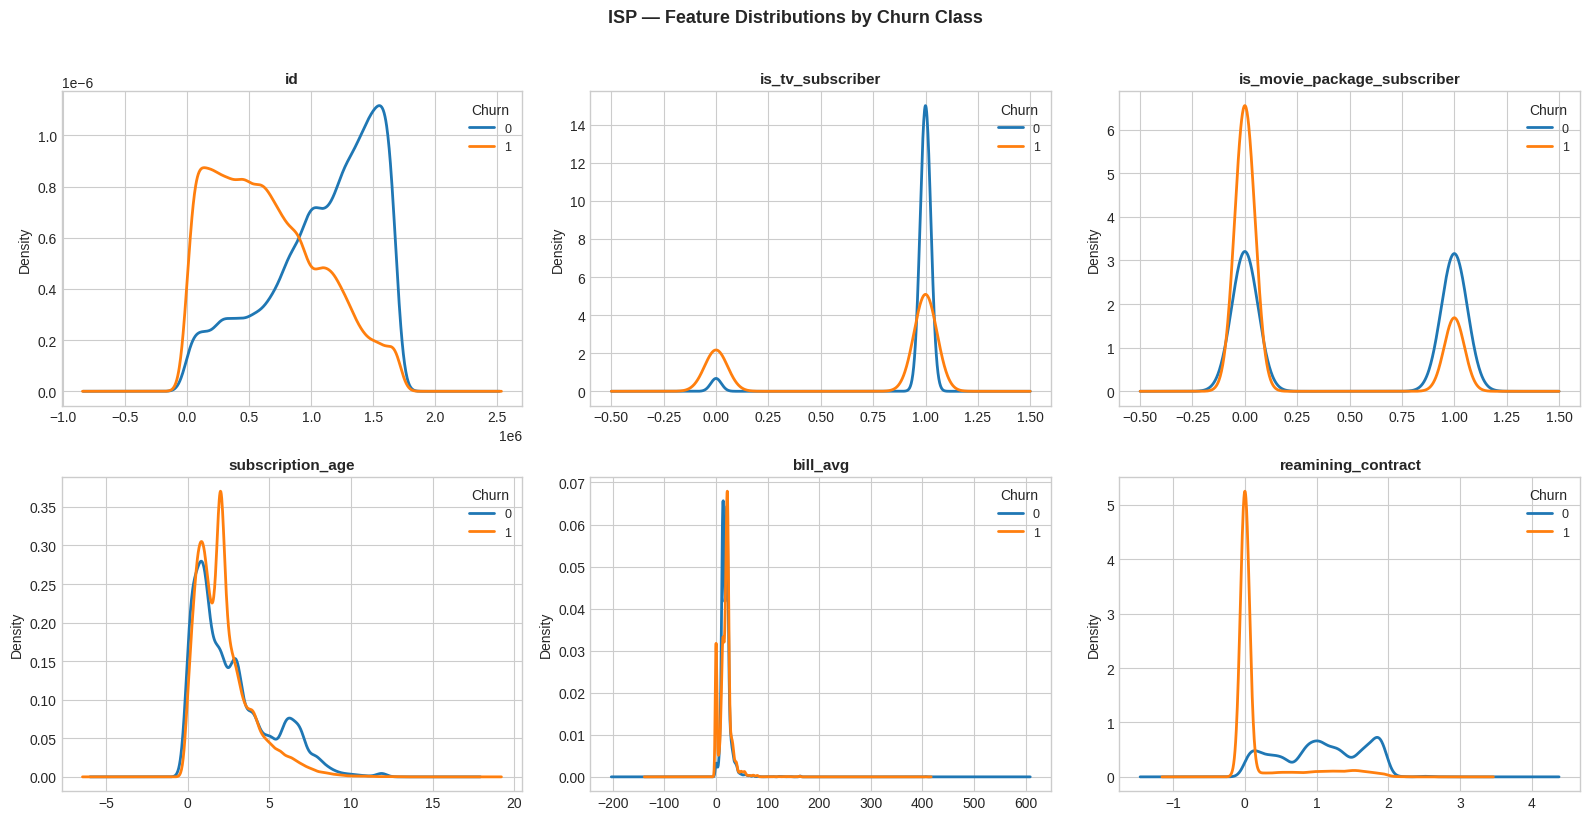

✓ Saved ISP distribution plot


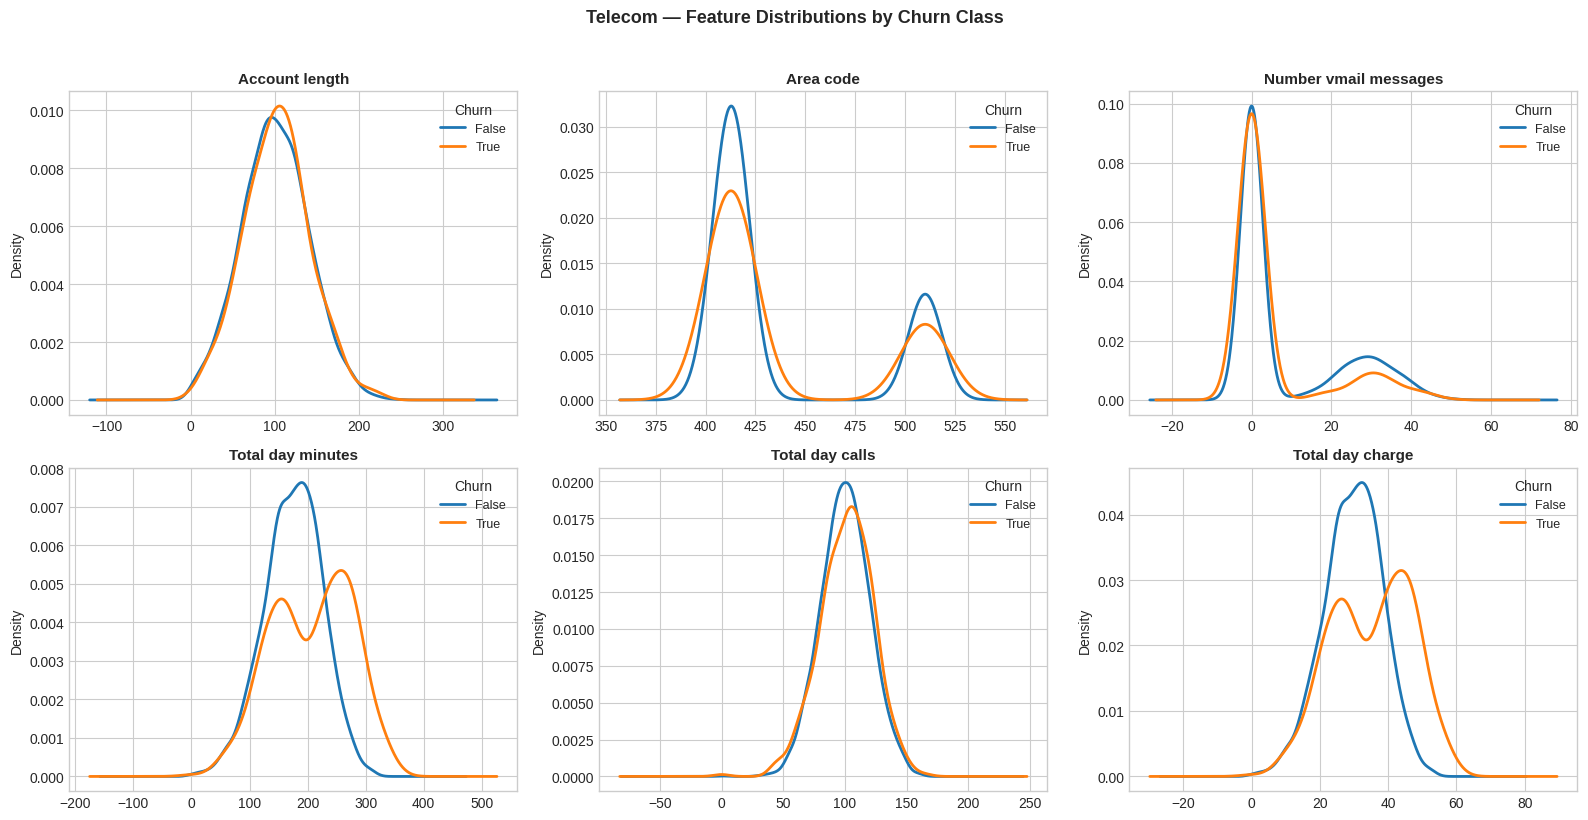

✓ Saved Telecom distribution plot


In [12]:
for name, df in datasets.items():
    churn_col  = churn_cols[name]
    numeric_cols = df.select_dtypes(include='number').columns.tolist()

    # remove churn column itself if numeric
    numeric_cols = [c for c in numeric_cols if c != churn_col][:6]

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        for label, grp in df.groupby(churn_col)[col]:
            grp.plot(kind='kde', ax=axes[i], label=str(label), linewidth=2)
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].legend(title='Churn', fontsize=9)

    plt.suptitle(f'{name} — Feature Distributions by Churn Class',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS + f'{name.lower()}_distributions.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved {name} distribution plot")

**Final EDA summary table**

In [13]:
summary = []
for name, df in datasets.items():
    churn_col  = churn_cols[name]
    churn_vals = df[churn_col]

    if churn_vals.dtype == bool:
        churn_rate = churn_vals.mean() * 100
    elif churn_vals.dtype == object:
        churn_rate = (
            churn_vals.str.strip()
                      .str.lower()
                      .isin(['yes', 'true', '1', 'churn'])
        ).mean() * 100
    else:
        churn_rate = (churn_vals > 0).mean() * 100

    summary.append({
        'Dataset'      : name,
        'Rows'         : df.shape[0],
        'Columns'      : df.shape[1],
        'Churn Col'    : churn_col,
        'Churn Rate %' : round(churn_rate, 1),
        'Missing Vals' : df.isnull().sum().sum(),
        'Numeric Cols' : df.select_dtypes(include='number').shape[1],
        'Object Cols'  : df.select_dtypes(include='object').shape[1]
    })

summary_df = pd.DataFrame(summary)
display(summary_df)
summary_df.to_csv(RESULTS + 'eda_summary.csv', index=False)
print("\n✓ EDA complete — saved to results/eda_summary.csv")
print("✓ Next: run 02_preprocessing notebook")

,Dataset,Rows,Columns,Churn Col,Churn Rate %,Missing Vals,Numeric Cols,Object Cols
0,Insurance,45211,17,labels,8.8,11303,17,0
1,ISP,72274,11,churn,55.4,22334,11,0
2,Telecom,3333,20,Churn,14.5,0,16,3



✓ EDA complete — saved to results/eda_summary.csv
✓ Next: run 02_preprocessing notebook
